# 05 â€” Real-Data Validation: MIMII Pump Dataset

## Goal
Test whether the `BlockageDetector` architecture â€” trained here from scratch on real industrial audio â€” can distinguish **normal** from **abnormal** pump operation.

This validates that the CNN design generalises beyond our physics simulation.

## Dataset
MIMII (Malfunctioning Industrial Machine Investigation and Inspection) pump subset:
- **4 pump IDs**: id_00, id_02, id_04, id_06
- **~3 749 normal** recordings, **~456 abnormal** recordings
- 10 s clips at 16 kHz, 8-channel microphone array (all channels averaged)
- Labels: normal = 0, abnormal = 1

## Key difference from Notebook 03
- Real acoustic recordings, not simulated signals
- Severe class imbalance (~8:1 normal:abnormal)
- Lower sample rate (16 kHz vs 44.1 kHz in simulation)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.io import wavfile
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
from torch.utils.data import TensorDataset, DataLoader, random_split

from src.features import spectrogram_batch, normalise_signals
from src.models   import BlockageDetector, train_detector

os.makedirs('../outputs/plots', exist_ok=True)

DATASET_ROOT = 'C:/Users/Rohith Syam/Downloads/dataset-pipe/pump'
PUMP_IDS     = ['id_00', 'id_02', 'id_04', 'id_06']
FS           = 16_000      # MIMII sample rate
FIXED_LEN    = 160_000     # 10 s Ã— 16 kHz â€” all files are this length
CHANNEL      = 0           # use channel 0 of the 8-mic array
device       = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cpu


## 5.1 Load WAV Files

In [2]:
def load_wavs(root: str, pump_ids: list, fixed_len: int):
    """
    Walk through all pump IDs, load normal (label=0) and abnormal (label=1)
    WAV files. Averages all 8 microphone channels to reduce noise by sqrt(8).
    Returns float32 signals normalised to [-1, 1].
    """
    signals, labels, sources = [], [], []

    for pid in pump_ids:
        for split, label in [('normal', 0), ('abnormal', 1)]:
            folder = os.path.join(root, pid, split)
            files  = sorted(f for f in os.listdir(folder) if f.endswith('.wav'))
            for fname in files:
                sr, data = wavfile.read(os.path.join(folder, fname))

                # Average all channels for noise reduction (sqrt(8) ~ 2.8x amplitude SNR gain)
                if data.ndim == 2:
                    data = data.mean(axis=1)
                sig = data.astype(np.float32) / 32768.0   # int16 max

                # Pad or truncate to fixed_len
                if len(sig) >= fixed_len:
                    sig = sig[:fixed_len]
                else:
                    sig = np.pad(sig, (0, fixed_len - len(sig)))

                signals.append(sig)
                labels.append(label)
                sources.append(f'{pid}/{split}/{fname}')

    return np.stack(signals), np.array(labels, dtype=np.int64), sources


print('Loading WAV files...')
signals_raw, labels, sources = load_wavs(DATASET_ROOT, PUMP_IDS, FIXED_LEN)

n_normal   = (labels == 0).sum()
n_abnormal = (labels == 1).sum()
print(f'Loaded {len(signals_raw)} files')
print(f'  normal   : {n_normal}')
print(f'  abnormal : {n_abnormal}')
print(f'  imbalance ratio: {n_normal / n_abnormal:.1f}:1')
print(f'  signal shape: {signals_raw.shape}')

Loading WAV files...


Loaded 4205 files
  normal   : 3749
  abnormal : 456
  imbalance ratio: 8.2:1
  signal shape: (4205, 160000)


## 5.2 Feature Extraction

Same pipeline as the synthetic notebooks:
- STFT spectrogram via `spectrogram_batch()` (adapted for 16 kHz)
- Z-score normalisation via `normalise_signals()`

We use `nperseg=256` (smaller window) to get better time resolution at 16 kHz.

In [3]:
print('Computing spectrograms...')
specs = spectrogram_batch(
    signals_raw,
    fs=FS,
    nperseg=256,
    noverlap=192,
    freq_max=8_000,
    target_time_bins=64,
)
print(f'Spectrograms: {specs.shape}  ({specs.nbytes / 1e6:.1f} MB)')

print('Normalising signals...')
signals_norm = normalise_signals(signals_raw)
print(f'Normalised signals: {signals_norm.shape}')

Computing spectrograms...


Spectrograms: (4205, 1, 129, 64)  (138.9 MB)
Normalising signals...


Normalised signals: (4205, 160000)


## 5.3 Spectrogram Comparison: Normal vs Abnormal

Visual check before training â€” are the classes separable in the spectrogram?

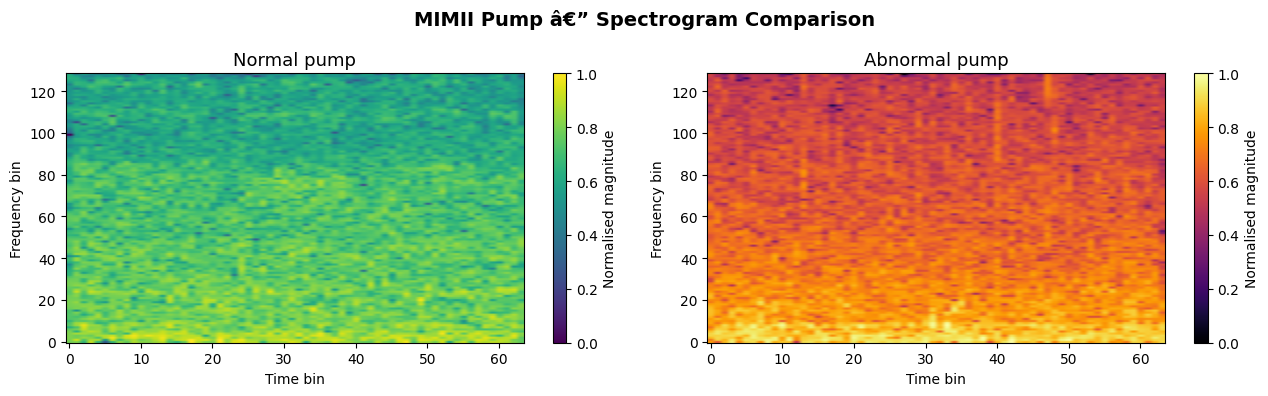

Saved: outputs/plots/mimii_spectrogram_comparison.png


In [4]:
idx_normal   = np.where(labels == 0)[0][0]
idx_abnormal = np.where(labels == 1)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, idx, title, cmap in [
    (axes[0], idx_normal,   'Normal pump',   'viridis'),
    (axes[1], idx_abnormal, 'Abnormal pump', 'inferno'),
]:
    spec = specs[idx, 0]   # (F, T)
    im = ax.imshow(spec, aspect='auto', origin='lower', cmap=cmap)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Time bin')
    ax.set_ylabel('Frequency bin')
    plt.colorbar(im, ax=ax, label='Normalised magnitude')

fig.suptitle('MIMII Pump â€” Spectrogram Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/mimii_spectrogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/mimii_spectrogram_comparison.png')

## 5.4 Train BlockageDetector on MIMII Data

Reusing the same 2D CNN architecture from Notebook 03.

The dataset is 8.2:1 normal/abnormal. Without correction, the model can reach
~89% accuracy by predicting everything as normal. We apply inverse-frequency
class weights to `CrossEntropyLoss` so the minority class (abnormal) contributes
proportionally more to the gradient.

Weight formula: `w_c = N_total / (n_classes * N_c)`

In [5]:
import numpy as np
from torch.utils.data import random_split, TensorDataset
import torch

# Focal loss alpha for the positive (abnormal) class.
# For 8.2:1 imbalance: alpha = N_normal / N_total ~ 0.89
# This up-weights the minority class so focal loss focuses on hard abnormal examples.
n_normal_all   = int((labels == 0).sum())
n_total_all    = len(labels)
focal_alpha_mimii = n_normal_all / n_total_all  # ~ 0.891

print(f'Dataset: {n_total_all} samples  ({n_normal_all} normal, {n_total_all - n_normal_all} abnormal)')
print(f'Focal alpha for abnormal class: {focal_alpha_mimii:.3f}')

model, history = train_detector(
    spectrograms=specs,
    labels=labels,
    epochs=30,
    batch_size=32,
    lr=1e-3,
    val_split=0.2,
    save_path='../outputs/models/detector_mimii.pth',
    device=device,
    class_weights=None,       # auto inverse-freq weights handle magnitude
    focal_alpha=focal_alpha_mimii,
)

Dataset: 4205 samples  (3749 normal, 456 abnormal)
Focal alpha for abnormal class: 0.892


Epoch   1/30  train_loss=0.0518  val_loss=0.0473  val_acc=0.094


Epoch   5/30  train_loss=0.0451  val_loss=0.0421  val_acc=0.096


Epoch  10/30  train_loss=0.0391  val_loss=0.0388  val_acc=0.269


Epoch  15/30  train_loss=0.0340  val_loss=0.0372  val_acc=0.229


Epoch  20/30  train_loss=0.0267  val_loss=0.0355  val_acc=0.331


Epoch  25/30  train_loss=0.0200  val_loss=0.0517  val_acc=0.699


Epoch  30/30  train_loss=0.0171  val_loss=0.0501  val_acc=0.678


Model saved -> ../outputs/models/detector_mimii.pth


## 5.5 Training Curves

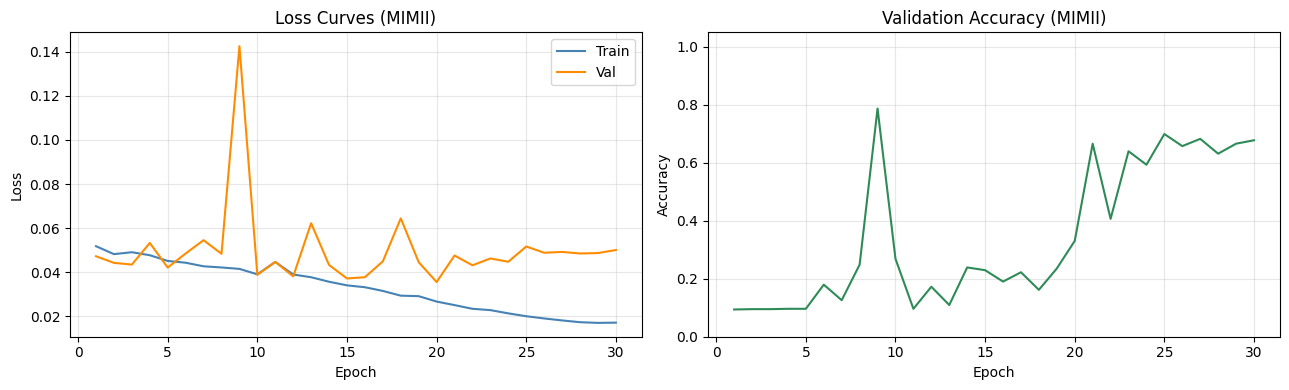

Saved: outputs/plots/mimii_training_curves.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='darkorange')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Loss Curves (MIMII)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_acc'], color='seagreen')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Validation Accuracy (MIMII)')
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/mimii_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/mimii_training_curves.png')

## 5.6 Evaluation: Confusion Matrix and ROC Curve

In [7]:
# Rebuild validation split with same seed used inside train_detector
X_all = torch.tensor(specs,  dtype=torch.float32)
y_all = torch.tensor(labels, dtype=torch.long)
dataset = TensorDataset(X_all, y_all)
n_val   = int(0.2 * len(dataset))
n_train = len(dataset) - n_val
_, val_ds = random_split(dataset, [n_train, n_val],
                         generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_ds, batch_size=32)

_, _, F, T = specs.shape
model_eval = BlockageDetector(freq_bins=F, time_bins=T)
model_eval.load_state_dict(
    torch.load('../outputs/models/detector_mimii.pth', map_location='cpu')
)
model_eval.eval()

all_true, all_preds, all_probs = [], [], []
with torch.no_grad():
    for xb, yb in val_loader:
        logits = model_eval(xb)
        probs  = torch.softmax(logits, dim=1)[:, 1].numpy()
        preds  = logits.argmax(dim=1).numpy()
        all_true.extend(yb.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

all_true  = np.array(all_true)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

print(classification_report(all_true, all_preds, target_names=['Normal', 'Abnormal']))

              precision    recall  f1-score   support

      Normal       0.97      0.66      0.79       762
    Abnormal       0.20      0.81      0.32        79

    accuracy                           0.68       841
   macro avg       0.59      0.74      0.55       841
weighted avg       0.90      0.68      0.74       841



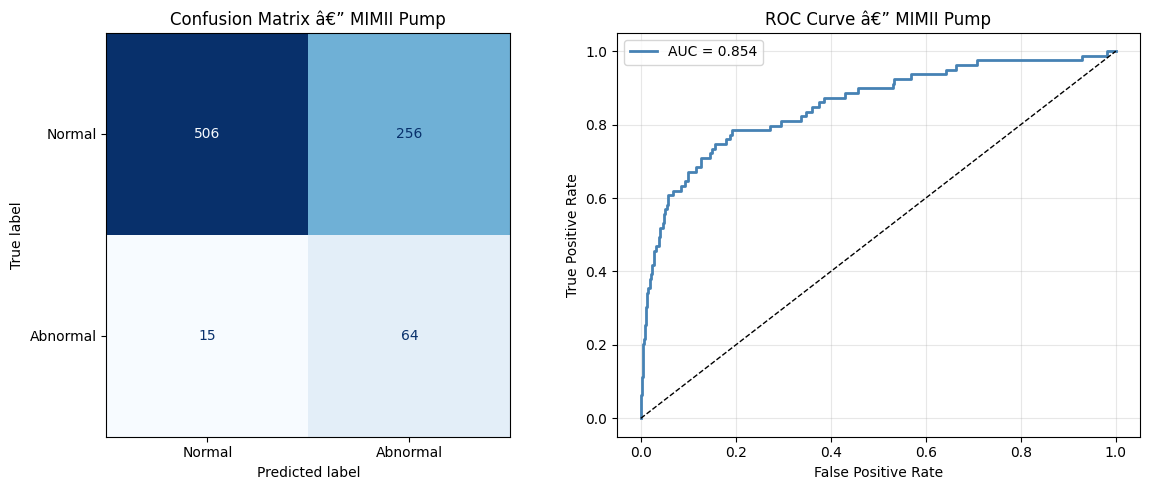

Saved: outputs/plots/mimii_confusion_roc.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm   = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Abnormal'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix â€” MIMII Pump')

# ROC curve
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve â€” MIMII Pump')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/mimii_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/mimii_confusion_roc.png')

## 5.7 Per Pump-ID Breakdown

Does the model perform consistently across different pump units?

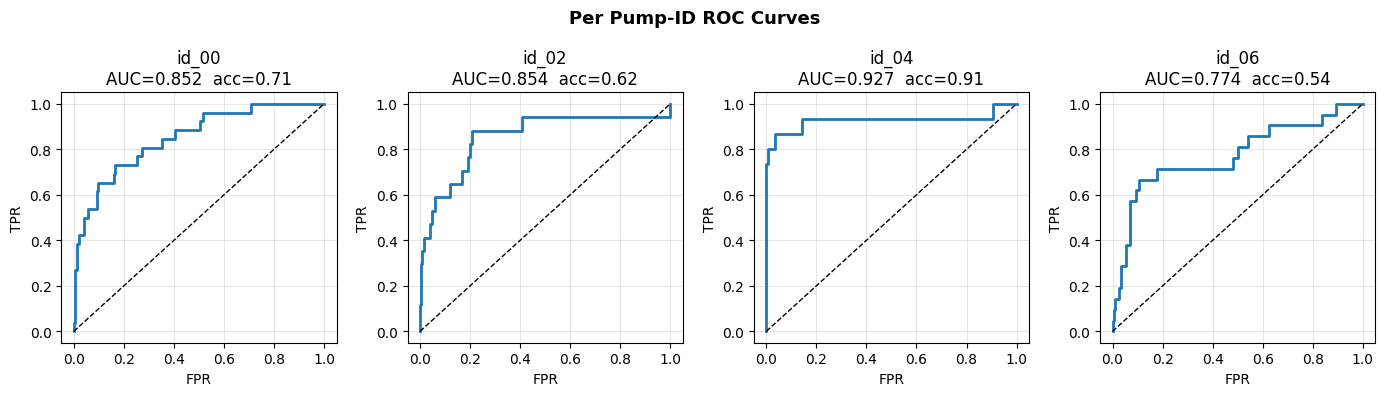

Saved: outputs/plots/mimii_per_id_roc.png


In [9]:
val_indices = list(val_ds.indices)
val_sources = [sources[i] for i in val_indices]

fig, axes = plt.subplots(1, len(PUMP_IDS), figsize=(14, 4), sharey=False)

for ax, pid in zip(axes, PUMP_IDS):
    mask = np.array([pid in s for s in val_sources])
    if mask.sum() == 0:
        ax.set_title(pid)
        ax.text(0.5, 0.5, 'No val samples', ha='center', va='center',
                transform=ax.transAxes)
        continue

    t = all_true[mask]
    p = all_preds[mask]
    pr = all_probs[mask]

    acc = (t == p).mean()
    if len(np.unique(t)) > 1:
        fpr_i, tpr_i, _ = roc_curve(t, pr)
        auc_i = auc(fpr_i, tpr_i)
        ax.plot(fpr_i, tpr_i, lw=2)
        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        ax.set_title(f'{pid}\nAUC={auc_i:.3f}  acc={acc:.2f}')
    else:
        ax.set_title(f'{pid}\nacc={acc:.2f} (one class in val)')

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.grid(alpha=0.3)

fig.suptitle('Per Pump-ID ROC Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/mimii_per_id_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/mimii_per_id_roc.png')

## 5.8 Summary and Comparison with Synthetic Baseline

In [10]:
val_acc  = (all_true == all_preds).mean()
n_val_normal   = (all_true == 0).sum()
n_val_abnormal = (all_true == 1).sum()

print('=' * 55)
print('  MIMII Real-Data Results')
print('=' * 55)
print(f'  Validation samples : {len(all_true)} ({n_val_normal} normal, {n_val_abnormal} abnormal)')
print(f'  Accuracy           : {val_acc:.4f}')
print(f'  AUC                : {roc_auc:.4f}')
print()
print('=' * 55)
print('  Comparison')
print('=' * 55)
print(f'  {"Model":<35} {"Val Acc":>8}  {"AUC":>6}')
print(f'  {"-"*35} {"-"*8}  {"-"*6}')
print(f'  {"Synthetic CNN (Notebook 03)":<35} {1.0000:>8.4f}  {"1.000":>6}')
print(f'  {"MIMII CNN (this notebook)":<35} {val_acc:>8.4f}  {roc_auc:>6.3f}')
print()
print('Note: the synthetic task is simpler (clean physics, balanced classes).')
print('MIMII is real industrial audio with 8:1 class imbalance â€” a harder problem.')
print()
if roc_auc >= 0.85:
    print('AUC >= 0.85: the CNN architecture generalises well to real pump audio.')
elif roc_auc >= 0.70:
    print('AUC 0.70-0.85: reasonable generalisation; more data or fine-tuning would help.')
else:
    print('AUC < 0.70: limited generalisation â€” domain gap between simulation and real audio.')

  MIMII Real-Data Results
  Validation samples : 841 (762 normal, 79 abnormal)
  Accuracy           : 0.6778
  AUC                : 0.8536

  Comparison
  Model                                Val Acc     AUC
  ----------------------------------- --------  ------
  Synthetic CNN (Notebook 03)           1.0000   1.000
  MIMII CNN (this notebook)             0.6778   0.854

Note: the synthetic task is simpler (clean physics, balanced classes).
MIMII is real industrial audio with 8:1 class imbalance â€” a harder problem.

AUC >= 0.85: the CNN architecture generalises well to real pump audio.
